In [3]:
import pandas as pd
from statsmodels.tsa.api import VARMAX
import statsmodels.api as sm
from matplotlib import pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

In [4]:
# download data
fruit = pd.read_csv("cleaned_produce.csv")
df = fruit.pivot_table(index="date", columns="productname", values="averageretail")

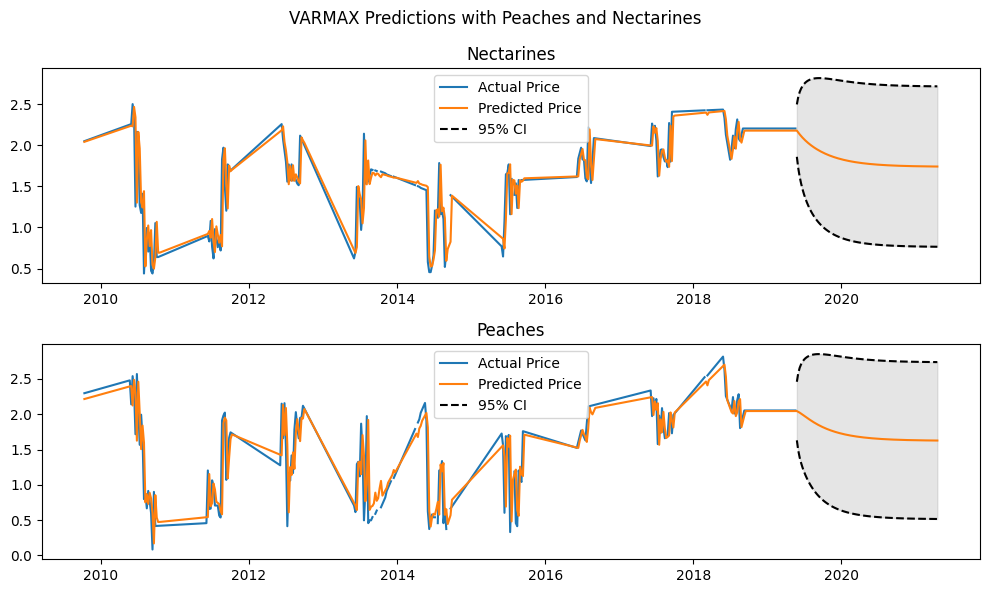

In [ ]:
# prediction for peaches and nectarines
y1, y2 = 'Peaches', 'Nectarines'
data = df[['Peaches', 'Nectarines']]
n_steps = 100

# handle dates for indexing, predict n future weeks
data.index = pd.to_datetime(data.index)
data = data.asfreq("W-SUN")
future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(weeks=1), periods=n_steps, freq="W-SUN")

# fit on both peach and nectarine data and get varmax predictions for each fruit
var_model = VARMAX(data).fit(disp=False)   
pred = var_model.predict(start=data.index[0], end=future_dates[-1])    

# get confidence interval
forecast_obj = var_model.get_forecast(steps=n_steps)
all_CI = forecast_obj.conf_int(alpha=0.05)

# plot peaches actual and predicted with confidence interval
fig, axs = plt.subplots(2, 1, figsize=(10, 6))

# Nectarines predicition with VARMAX
axs[0].plot(data.iloc[10*52:]['Nectarines'], label='Actual Price')
axs[0].plot(pred.iloc[10*52:]['Nectarines'], label='Predicted Price')
axs[0].plot(future_dates, all_CI['lower Nectarines'], c="k", linestyle='--')
axs[0].plot(future_dates, all_CI['upper Nectarines'], c="k", linestyle='--', label="95% CI")
axs[0].set_title('Nectarines')

axs[0].fill_between(future_dates,
                 all_CI['lower Nectarines'],
                 all_CI['upper Nectarines'],
                 color='gray', alpha=0.2)
axs[0].legend()

# Peaches predicition with VARMAX
axs[1].plot(data.iloc[10*52:]['Peaches'], label='Actual Price')
axs[1].plot(pred.iloc[10*52:]['Peaches'], label='Predicted Price')
axs[1].plot(future_dates, all_CI['lower Peaches'], c="k", linestyle='--')
axs[1].plot(future_dates, all_CI['upper Peaches'], c="k", linestyle='--', label="95% CI")
axs[1].set_title('Peaches')

axs[1].fill_between(future_dates,
                 all_CI['lower Peaches'],
                 all_CI['upper Peaches'],
                 color='gray', alpha=0.2)

# plotting
plt.suptitle('VARMAX Predictions with Peaches and Nectarines')
plt.tight_layout()
plt.show()

/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


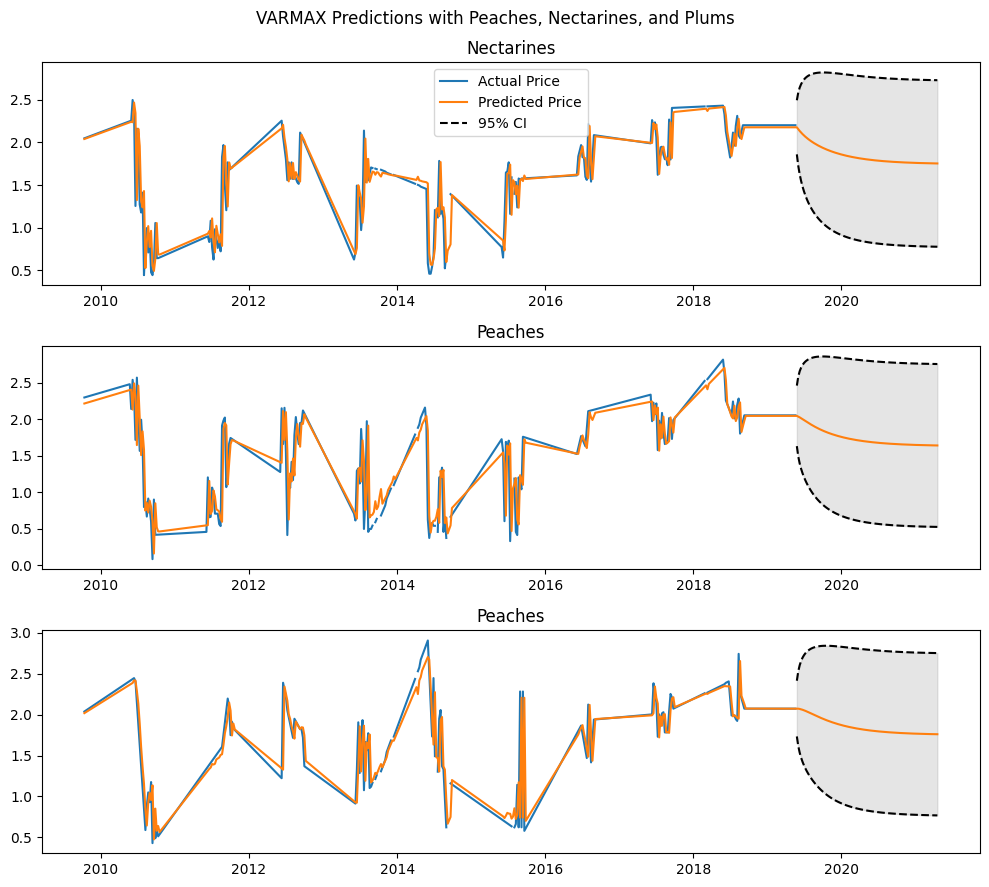

In [25]:
# prediction for peaches and nectarines
data = df[['Peaches', 'Nectarines', 'Plums']]
n_steps = 100

# handle dates for indexing, predict n future weeks
data.index = pd.to_datetime(data.index)
data = data.asfreq("W-SUN")
future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(weeks=1), periods=n_steps, freq="W-SUN")

# fit on both peach and nectarine data and get varmax predictions for each fruit
var_model = VARMAX(data).fit(disp=False)   
pred = var_model.predict(start=data.index[0], end=future_dates[-1])    

# get confidence interval
forecast_obj = var_model.get_forecast(steps=n_steps)
all_CI = forecast_obj.conf_int(alpha=0.05)

# plot peaches actual and predicted with confidence interval
fig, axs = plt.subplots(3, 1, figsize=(10, 9))

# Nectarines predicition with VARMAX
axs[0].plot(data.iloc[10*52:]['Nectarines'], label='Actual Price')
axs[0].plot(pred.iloc[10*52:]['Nectarines'], label='Predicted Price')
axs[0].plot(future_dates, all_CI['lower Nectarines'], c="k", linestyle='--')
axs[0].plot(future_dates, all_CI['upper Nectarines'], c="k", linestyle='--', label="95% CI")
axs[0].set_title('Nectarines')

axs[0].fill_between(future_dates,
                 all_CI['lower Nectarines'],
                 all_CI['upper Nectarines'],
                 color='gray', alpha=0.2)
axs[0].legend()

# Peaches predicition with VARMAX
axs[1].plot(data.iloc[10*52:]['Peaches'], label='Actual Price')
axs[1].plot(pred.iloc[10*52:]['Peaches'], label='Predicted Price')
axs[1].plot(future_dates, all_CI['lower Peaches'], c="k", linestyle='--')
axs[1].plot(future_dates, all_CI['upper Peaches'], c="k", linestyle='--', label="95% CI")
axs[1].set_title('Peaches')

axs[1].fill_between(future_dates,
                 all_CI['lower Peaches'],
                 all_CI['upper Peaches'],
                 color='gray', alpha=0.2)

# Peaches predicition with VARMAX
axs[2].plot(data.iloc[10*52:]['Plums'], label='Actual Price')
axs[2].plot(pred.iloc[10*52:]['Plums'], label='Predicted Price')
axs[2].plot(future_dates, all_CI['lower Plums'], c="k", linestyle='--')
axs[2].plot(future_dates, all_CI['upper Plums'], c="k", linestyle='--', label="95% CI")
axs[2].set_title('Peaches')

axs[2].fill_between(future_dates,
                 all_CI['lower Plums'],
                 all_CI['upper Plums'],
                 color='gray', alpha=0.2)
# plotting
plt.suptitle('VARMAX Predictions with Peaches, Nectarines, and Plums')
plt.tight_layout()
plt.show()

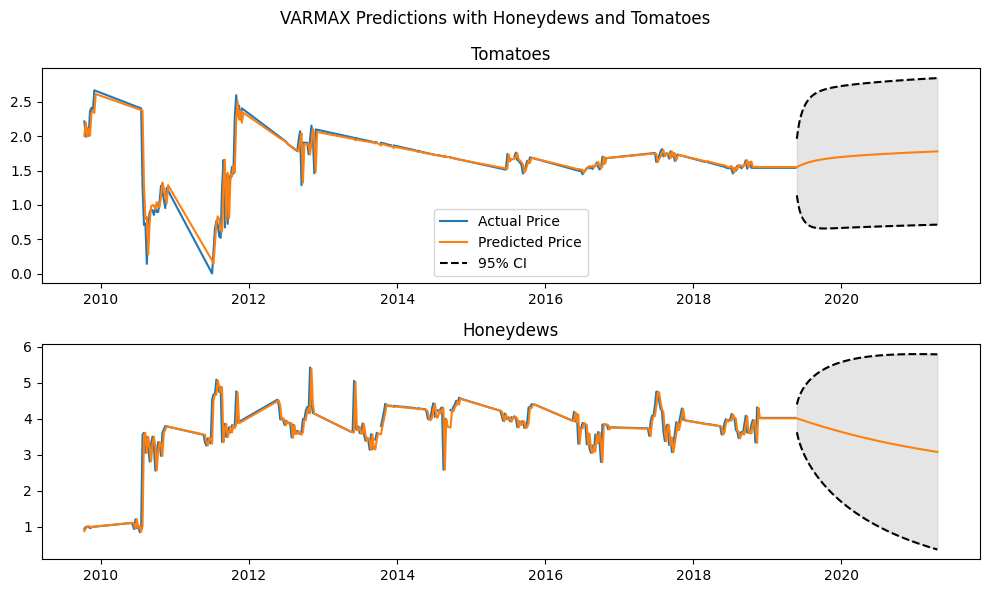

In [27]:
# prediction for peaches and nectarines
data = df[['Honeydews', 'Tomatoes']]
n_steps = 100

# handle dates for indexing, predict n future weeks
data.index = pd.to_datetime(data.index)
data = data.asfreq("W-SUN")
future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(weeks=1), periods=n_steps, freq="W-SUN")

# fit on both peach and nectarine data and get varmax predictions for each fruit
var_model = VARMAX(data).fit(disp=False)   
pred = var_model.predict(start=data.index[0], end=future_dates[-1])    

# get confidence interval
forecast_obj = var_model.get_forecast(steps=n_steps)
all_CI = forecast_obj.conf_int(alpha=0.05)

# plot peaches actual and predicted with confidence interval
fig, axs = plt.subplots(2, 1, figsize=(10, 6))

# Tomatoes predicition with VARMAX
axs[0].plot(data.iloc[10*52:]['Tomatoes'], label='Actual Price')
axs[0].plot(pred.iloc[10*52:]['Tomatoes'], label='Predicted Price')
axs[0].plot(future_dates, all_CI['lower Tomatoes'], c="k", linestyle='--')
axs[0].plot(future_dates, all_CI['upper Tomatoes'], c="k", linestyle='--', label="95% CI")
axs[0].set_title('Tomatoes')

axs[0].fill_between(future_dates,
                 all_CI['lower Tomatoes'],
                 all_CI['upper Tomatoes'],
                 color='gray', alpha=0.2)
axs[0].legend()

# Honeydews predicition with VARMAX
axs[1].plot(data.iloc[10*52:]['Honeydews'], label='Actual Price')
axs[1].plot(pred.iloc[10*52:]['Honeydews'], label='Predicted Price')
axs[1].plot(future_dates, all_CI['lower Honeydews'], c="k", linestyle='--')
axs[1].plot(future_dates, all_CI['upper Honeydews'], c="k", linestyle='--', label="95% CI")
axs[1].set_title('Honeydews')

axs[1].fill_between(future_dates,
                 all_CI['lower Honeydews'],
                 all_CI['upper Honeydews'],
                 color='gray', alpha=0.2)

# plotting
plt.suptitle('VARMAX Predictions with Honeydews and Tomatoes')
plt.tight_layout()
plt.show()